# Somerville processed permits — summary & outlier triage

Reads `data/processed/ma/somerville/joined_data.csv` (the output of
`make process-somerville`) and answers two questions:

**a)** Does the processed table look right — did the residential filter, the project-type
regexes, and the assessor join do what they were supposed to?

**b)** Which rows are outliers, and where should the cutoffs go?

Sections 1–5 are read-only diagnostics. **Section 6 is the workbench**: one `PARAMS`
dict of thresholds, and every downstream cell reports what those thresholds actually
cost you. Tune `PARAMS`, re-run from there down, and look at the numbers again.

A note on shape, because it drives most of what follows: one row is **one permit**, not
one building. The assessor attributes are joined on, so a 125-unit building contributes
its `res_area` once per permit filed against it. Anything that looks like a fat tail in
`res_area` is usually a big building with a lot of permits, not a bad value.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)

# Validated categorical slots, assigned in fixed order and never cycled.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.figsize": (9, 3.4),
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d8d7d2",     # recessive grid, behind the marks
    "grid.linewidth": 0.6,
    "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titlesize": 11,
    "axes.labelcolor": MUTED,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "lines.linewidth": 2,
})

CSV = Path("../data/processed/ma/somerville/joined_data.csv")

# One boolean column per project type. Independent: a permit can carry several
# flags or none, and all-false is the residual "no equipment named" bucket.
# Mirrors PROJECT_TYPE_PATTERNS order in the pipeline.
FLAGS = [
    "solar_pv", "heat_pumps", "heat_pump_water_heater", "water_heater", "cooking",
    "ev_charger", "electrical_panel", "other_hvac", "ess",
]
# Extracted magnitudes, populated only on the rows whose flag they belong to.
SIZE_COLS = ["solar_kw", "ess_kwh"]

# Short aliases so the 9x9 co-occurrence matrix stays readable in a terminal.
SHORT = {
    "heat_pump_water_heater": "hpwh", "water_heater": "wtr_heat",
    "electrical_panel": "panel", "ev_charger": "ev", "solar_pv": "solar",
    "heat_pumps": "heat_pump", "other_hvac": "oth_hvac", "cooking": "cook", "ess": "ess",
}

In [2]:
df = pd.read_csv(CSV, low_memory=False)
df["application_date"] = pd.to_datetime(df["application_date"], errors="coerce")
df[FLAGS] = df[FLAGS].astype(bool)

# A compact label for display only -- "solar_pv+electrical_panel", or "untagged".
# Never filter on this; filter on the boolean columns.
df["flag_label"] = (
    df[FLAGS].apply(lambda r: "+".join(c for c in FLAGS if r[c]), axis=1).replace("", "untagged")
)
n_flags = df[FLAGS].sum(axis=1)

# NB: `style` is a real column here and `df.style` is the pandas Styler.
# Always reach for it as df["style"].
print(f"{len(df):,} rows x {df.shape[1]} columns from {CSV}")
print(f"date range: {df['application_date'].min():%Y-%m-%d} to {df['application_date'].max():%Y-%m-%d}")
df.head(3)

62,050 rows x 36 columns from ../data/processed/ma/somerville/joined_data.csv
date range: 2014-02-13 to 2026-09-03


,application_number,application_date,application_type,application_subtype,project_description,solar_pv,heat_pumps,heat_pump_water_heater,water_heater,cooking,ev_charger,electrical_panel,other_hvac,ess,solar_kw,ess_kwh,address,apn,parcel_key,parcel_prefix,latitude,longitude,company_name,company_source,match_level,assess_records,loc_id,prop_id,year_built,res_area,num_rooms,style,use_code,stories,units,flag_label
0,E14-001179,2014-11-03,Electrical Permit,Residential,wire bathrooms,False,False,False,False,False,False,False,False,False,NaN,NaN,"297 ALEWIFE BROOK PKWY, SOMERVILLE MASSACHUSETTS",004-B-00044-000000,4-B-44,4-B-44,42.409577,-71.130242,Robert Nazzaro,contractor,unit,1.0,F_756023_2974493,4_B_44,1920.0,2060.0,11.0,2-Decker,1040,2.0,0.0,untagged
1,E14-001180,2014-11-03,Electrical Permit,Residential,Installing 24 PV solar panels on roof. 5.98KW system.,True,False,False,False,False,False,False,False,False,5.98,NaN,"35 GORDON ST, SOMERVILLE MASSACHUSETTS 02144",003-B-00024-000000,3-B-24,3-B-24,42.412717,-71.128635,"Roof Diagnostics Solar of Mass, LLC/NRG Home Solar",contractor,unit,1.0,F_756454_2975643,3_B_24,1930.0,3130.0,10.0,Two Family,1040,2.5,0.0,solar_pv
2,B14-001250,2014-11-03,Building Permit,Residential Other,Replace decking boards on existing deck. Extend existing deck. ( 7' x 9' extension) re...,False,False,False,False,False,False,False,False,False,NaN,NaN,"17 CHERRY ST, SOMERVILLE MASSACHUSETTS 02144",030-E-00016-000000,30-E-16,30-E-16,42.389956,-71.115570,Absolute Construction Co.,contractor,unit,1.0,F_760014_2967359,30_E_16,1900.0,2057.0,10.0,2 Fam Conv,1040,1.8,0.0,untagged


## 1. Completeness

Two different kinds of "missing" live in this table and they need separating:

- **NaN** — the join found nothing, or the source cell was blank.
- **0** — the assessor wrote a zero. In the MassGIS CAMA extract a zero in `res_area`,
  `num_rooms`, or `units` is a *missing-value sentinel*, not a measurement. A house with
  0 rooms does not exist; a row with `res_area == 0` is an unpopulated record.

Anything with a high zero rate is a column you should not filter on, and probably should
not model on either.

In [3]:
def completeness(frame: pd.DataFrame) -> pd.DataFrame:
    """Per-column null rate, zero rate (numerics), and cardinality."""
    rows = []
    for col in frame.columns:
        s = frame[col]
        # Bools are numeric to pandas, but "zero" on a flag column just means
        # False and is already covered by its count -- so skip them.
        numeric = pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s)
        zero = (s == 0).sum() if numeric else np.nan
        rows.append({
            "dtype": str(s.dtype),
            "null": s.isna().sum(),
            "null_%": round(s.isna().mean() * 100, 2),
            "zero": zero,
            "zero_%": round(zero / len(frame) * 100, 2) if zero == zero else np.nan,
            "n_unique": s.nunique(dropna=True),
        })
    return pd.DataFrame(rows, index=frame.columns)

completeness(df)

,dtype,null,null_%,zero,zero_%,n_unique
application_number,str,0,0.00,NaN,NaN,62050
application_date,datetime64[us],6,0.01,NaN,NaN,4308
application_type,str,0,0.00,NaN,NaN,4
application_subtype,str,0,0.00,NaN,NaN,9
project_description,str,18,0.03,NaN,NaN,50624
solar_pv,bool,0,0.00,NaN,NaN,2
heat_pumps,bool,0,0.00,NaN,NaN,2
heat_pump_water_heater,bool,0,0.00,NaN,NaN,2
water_heater,bool,0,0.00,NaN,NaN,2
cooking,bool,0,0.00,NaN,NaN,2


**What to look at here**

- `company_name` is the coalesce of the raw contractor and applicant columns, which the
  pipeline now does for you. Only Building and Electrical permits populate a contractor;
  on Gas Fitting and Plumbing it is empty on *every* row and the applicant is the only
  party named. Read alone, the old contractor column made a third of the file look
  anonymous. `company_source` says which column each name came from -- see section 2.1.
- `stories` is missing on ~27% of rows because the pipeline maps the assessor's `0`
  sentinel to NA. That is correct behaviour, but it means `stories` is unusable as a
  filter key — you would drop a quarter of the data for a reason unrelated to the permit.
- `units` is ~0 on nearly every row. It is not a building unit count in this extract.
  Treat it as unpopulated and ignore it.

## 2. Permit-side sanity

Before touching the assessor attributes: is the permit half of the table the set of rows
we meant to keep? The pipeline filters to four trade families and to a `Residential`
occupancy class parsed out of the subtype string, so both of those are worth confirming.

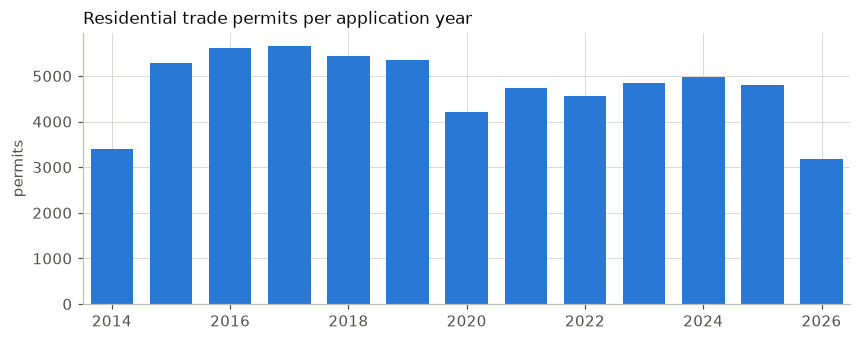

application_date,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0,2026.0
permits,3398,5286,5610,5659,5447,5352,4202,4744,4569,4835,4971,4798,3173


In [4]:
by_year = df["application_date"].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(by_year.index, by_year.values, color=BLUE, width=0.72)
ax.set_title("Residential trade permits per application year")
ax.set_ylabel("permits")
ax.margins(x=0.01)
plt.show()

by_year.to_frame("permits").T

The series is flat at ~4,500–5,600/yr with two explicable dents: 2020 (COVID) and the
first and last years, which are partial. **2026 is a partial year** — the extract was
pulled 2026-09-03. Any per-year rate you compute needs 2026 either annualized or dropped;
it is not a real decline.

2014 is also suspiciously low for a full year, which usually means the city's system
went live mid-year. Check the earliest months before you treat 2014 as a complete
baseline.

In [5]:
early = df[df["application_date"] < "2015-01-01"]
early_by_month = early["application_date"].dt.to_period("M").value_counts().sort_index()
print("Permits per month in the first year of the extract:")
print(early_by_month.to_string())

Permits per month in the first year of the extract:
application_date
2014-02      1
2014-03     33
2014-04     85
2014-05    214
2014-06    494
2014-07    468
2014-08    414
2014-09    514
2014-10    474
2014-11    360
2014-12    341
Freq: M


In [6]:
pd.crosstab(df["application_type"], df["application_subtype"]).replace(0, "").T

application_type,Building Permit,Electrical Permit,Gas Fitting,Plumbing Permit
application_subtype,,,,
Residential,,18392,,
Residential - Existing,,,8130,9322
Residential - New,,,547,660
Residential Addition,563,,,
Residential Alteration,3847,,,
Residential New Construction,572,,,
Residential Other,3612,,,
Residential Renovation,4242,,,
Residential Repair,12163,,,


Every subtype in the table should read as residential. If a `Commercial` or `Institutional`
value appears above, the first-word parse in `filter_residential` has a case it does not
handle and the fix belongs in the pipeline, not in an outlier filter here.

In [7]:
# Structural integrity checks -- each of these should be 0 or explainable.
checks = {
    "duplicate application_number": df["application_number"].duplicated().sum(),
    "null application_date": df["application_date"].isna().sum(),
    "null project_description": df["project_description"].isna().sum(),
    "null apn": df["apn"].isna().sum(),
    "null lat/lon": df["latitude"].isna().sum(),
    "no company named at all": df["company_name"].isna().sum(),
    "date in the future": (df["application_date"] > pd.Timestamp.today()).sum(),
}
pd.Series(checks, name="rows").to_frame()

,rows
duplicate application_number,0
null application_date,6
null project_description,18
null apn,50
null lat/lon,74
no company named at all,2680
date in the future,0


### 2.1 Who is named on the permit?

`company_name` coalesces two raw columns, contractor first. The merge is only sound if
the gap it fills is *structural* -- one trade recording the party in a different field --
rather than a genuine absence that the fallback papers over. This checks that.

In [8]:
src = df["company_source"].fillna("none")
by_type = pd.crosstab(df["application_type"], src)
by_type["% named"] = ((1 - by_type.get("none", 0) / by_type.sum(axis=1)) * 100).round(1)
print("Where the company name came from, by trade:")
print(by_type.to_string())

print(f"\ncoverage: {df['company_name'].notna().mean() * 100:.1f}% of permits name a party")
print(f"  contractor column alone would give: "
      f"{(src == 'contractor').mean() * 100:.1f}%")

Where the company name came from, by trade:
company_source     applicant  contractor  none  % named
application_type                                       
Building Permit          387       22641  1971     92.1
Electrical Permit         87       18193   112     99.4
Gas Fitting             8419           0   258     97.0
Plumbing Permit         9643           0   339     96.6

coverage: 95.7% of permits name a party
  contractor column alone would give: 65.8%


The split should fall cleanly along trade lines: **Gas Fitting and Plumbing supply
`applicant` on essentially every row**, because those permit types have no contractor
field populated at all, while Building and Electrical supply `contractor`. That is what
makes this a coalesce rather than a guess -- the fallback is picking up a column the
trade actually uses, not substituting a different kind of party.

The rows left at `none` are permits that name nobody in either column. They are a real
gap, not a merge artifact, and the filter workbench can drop them if you need a party.

In [9]:
# Both columns present and disagreeing -- the case the coalesce silently resolves in
# favour of the contractor. Mostly the same firm written two ways, occasionally a
# genuine agent-vs-installer distinction.
# The two source columns are inputs to the pipeline, not outputs, so pull them from the
# raw extract and line them up on application number.
RAW_PERMITS = sorted(Path("../data/raw/ma/somerville/permits").glob("*.csv"))[-1]
raw = (
    pd.read_csv(RAW_PERMITS, dtype=str, low_memory=False,
                usecols=["Application Number", "Contractor Company Name", "Applicant Company Name"])
    # 61 application numbers repeat in the raw extract; the processed table has none,
    # so keep the first and line up on the number.
    .drop_duplicates("Application Number")
    .set_index("Application Number")
    .reindex(df["application_number"])
    .set_axis(df.index)
)
c = raw["Contractor Company Name"].str.strip().replace("", pd.NA)
a = raw["Applicant Company Name"].str.strip().replace("", pd.NA)
differ = c.notna() & a.notna() & (c != a)
print(f"{int(differ.sum()):,} rows name a different contractor and applicant "
      f"({differ.mean() * 100:.1f}% of the table); company_name keeps the contractor.\n")
print(raw.loc[differ].sample(min(10, int(differ.sum())), random_state=0).to_string())

6,061 rows name a different contractor and applicant (9.8% of the table); company_name keeps the contractor.

                                             Applicant Company Name               Contractor Company Name
27753                                              HomeWorks Energy               CLEAN TECH CONSTRUCTION
52555  Revise Home Energy Solutions, Inc., Revise Heating & Cooling        Dipietro Home Energy Solutions
52416                                                 Viola Roofing         Viola Roofing and Contracting
22932  Revise Home Energy Solutions, Inc., Revise Heating & Cooling  DiPietro Home Energy Solutions, Inc.
50269                                                 Viola Roofing         Viola Roofing and Contracting
18392                                        Williams/Armstrong co.           Historical Slate Roofing Co
37431                                                  Vivint Solar          Vivint Solar Development LLC
48131                                     

Skim that sample. Most pairs are the same firm with punctuation or trailing-space
differences, which is harmless. A minority are a genuine agent filing on an installer's
behalf -- if your question is "which installers are active", the contractor is the right
pick and the coalesce already makes it; if it is "who filed", you want the raw applicant
column, which is still in the CSV the pipeline reads but no longer in its output.

## 3. Project-type flag audit

The project types are **nine independent boolean columns**, not one label. A permit that
upgrades the service *and* hangs an EV charger flags both; a permit whose description
names no equipment ("renovation", "rewire 3 units") flags none. That residual is still
the majority of the table.

Three things shape this audit:

- **Nothing shadows anything.** Every pattern is evaluated against every row, so precision
  rests entirely on the patterns themselves. Section 3.4 probes that directly.
- **The columns are not a partition**, so counts sum to more than the rows they cover.
  Anything treating them as mutually exclusive -- a pie chart, a share-of-total, a
  groupby -- is wrong. Use per-flag rates against the full row count.
- **Three pairs are deliberately related**, and the relationships are what make the
  flags summable. They are asserted in 3.2 rather than assumed:
  - `other_hvac` is masked to exclude `heat_pumps` (a mini-split *is* a condenser).
  - `heat_pump_water_heater` should be a strict subset of `water_heater` -- the
    electrified slice of a total end use.
  - `heat_pumps` (space conditioning) should exclude `heat_pump_water_heater`
    (water heating), via a lookahead in the heat-pump pattern.

`ess` is built differently from the other eight -- negation-scrubbed text, and a bare
"battery" only counts on a permit that is already solar -- so it gets its own section (3.5).

### 3.1 How often does each flag fire?

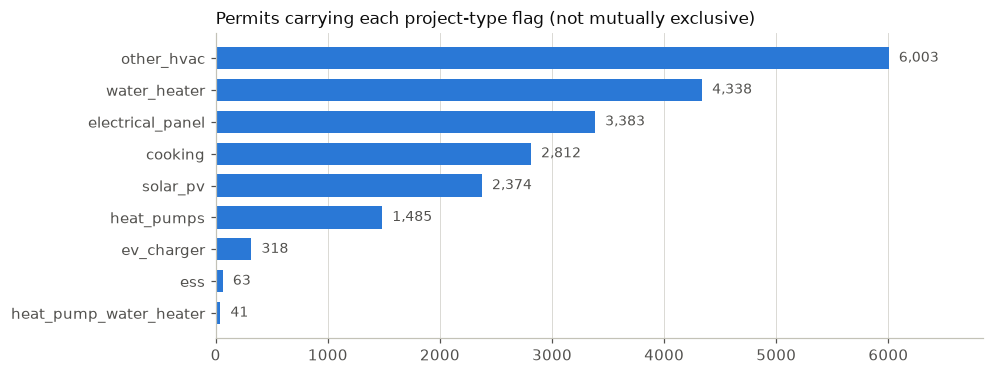

,permits,% of all rows
other_hvac,6003,9.67
water_heater,4338,6.99
electrical_panel,3383,5.45
cooking,2812,4.53
solar_pv,2374,3.83
heat_pumps,1485,2.39
ev_charger,318,0.51
ess,63,0.10
heat_pump_water_heater,41,0.07


In [10]:
counts = df[FLAGS].sum().sort_values()
rate = (counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(counts.index, counts.values, color=BLUE, height=0.7)
for label, v in zip(counts.index, counts.values):
    ax.text(v + counts.max() * 0.015, label, f"{v:,}", va="center", fontsize=9, color=MUTED)
ax.set_title("Permits carrying each project-type flag (not mutually exclusive)")
ax.set_xlim(0, counts.max() * 1.14)
ax.grid(axis="y", visible=False)
plt.show()

pd.DataFrame({"permits": counts, "% of all rows": rate}).sort_values("permits", ascending=False)

In [11]:
# How many flags does a row carry? Counts must be read against this, not summed.
dist = n_flags.value_counts().sort_index()
pd.DataFrame({
    "rows": dist,
    "% of table": (dist / len(df) * 100).round(2),
}).rename_axis("flags on the row")

,rows,% of table
flags on the row,,
0,43918,70.78
1,16001,25.79
2,1583,2.55
3,543,0.88
4,4,0.01
5,1,0.00


About 70% of rows carry **no flag**. That is expected and is not a failure of the rules --
most residential permits are kitchens, bathrooms, roofs, and decks that no pattern
targets. The untagged share dropped sharply when `water_heater` and `cooking` were added,
because those two are high-frequency appliance work that was previously invisible.

The number to interrogate is not the size of the untagged bucket; it is whether the nine
flags are *complete* (3.3) and *clean* (3.4).

### 3.2 Which flags co-occur, and do the nesting rules hold?

The diagonal is each flag's own total; off-diagonal cells are permits carrying both.

In [12]:
co = pd.DataFrame(
    {a: {b: int((df[a] & df[b]).sum()) for b in FLAGS} for a in FLAGS}, index=FLAGS,
)[FLAGS].rename(index=SHORT, columns=SHORT)
print("Co-occurrence counts (diagonal = flag total):")
print(co.to_string())

# Of the rows carrying the ROW flag, what % also carry the column's?
# Mask the diagonal rather than writing into .values -- that array is read-only.
pct = (co.div(np.diag(co), axis=0) * 100).round(1)
pct = pct.mask(np.eye(len(FLAGS), dtype=bool))
print("\n% of the row flag's permits that also carry the column flag:")
print(pct.to_string(na_rep="--"))

Co-occurrence counts (diagonal = flag total):
           solar  heat_pump  hpwh  wtr_heat  cook   ev  panel  oth_hvac  ess
solar       2374          1     0         3     0    4     37         0   48
heat_pump      1       1485    12        39     6   11    130         0    0
hpwh           0         12    41        41     0    0      4         5    0
wtr_heat       3         39    41      4338   640    4     42      1065    0
cook           0          6     0       640  2812    6     61       802    0
ev             4         11     0         4     6  318    114         4    2
panel         37        130     4        42    61  114   3383       165    0
oth_hvac       0          0     5      1065   802    4    165      6003    0
ess           48          0     0         0     0    2      0         0   63

% of the row flag's permits that also carry the column flag:
           solar  heat_pump  hpwh  wtr_heat  cook   ev  panel  oth_hvac  ess
solar         --        0.0   0.0       0.1  

In [13]:
# The relationships the pipeline promises. Each should be 0 rows.
violations = {
    "other_hvac AND heat_pumps (masked in pipeline)":
        df["other_hvac"] & df["heat_pumps"],
    "heat_pump_water_heater NOT IN water_heater (should be a strict subset)":
        df["heat_pump_water_heater"] & ~df["water_heater"],
    "heat_pumps AND heat_pump_water_heater (space vs water heating)":
        df["heat_pumps"] & df["heat_pump_water_heater"],
    "flag column with a null":
        pd.Series(df[FLAGS].isna().any(axis=1), index=df.index),
}
pd.Series({k: int(v.sum()) for k, v in violations.items()}, name="rows").to_frame()

,rows
other_hvac AND heat_pumps (masked in pipeline),0
heat_pump_water_heater NOT IN water_heater (should be a strict subset),0
heat_pumps AND heat_pump_water_heater (space vs water heating),12
flag column with a null,0


In [14]:
# Inspect whichever invariant above is non-zero.
overlap = df["heat_pumps"] & df["heat_pump_water_heater"]
print(f"{int(overlap.sum())} rows carry both heat_pumps and heat_pump_water_heater:\n")
for text in df.loc[overlap, "project_description"]:
    print(" *", " ".join(str(text).split())[:150])

12 rows carry both heat_pumps and heat_pump_water_heater:

 * Service Upgrade to 400A, 200A main panel for Unit 2 only. Install A/ C disconnect for heat pump. Wire a heat pump water heater.
 * Replace gas water heater with heat pump
 * Wiring replacement Heat Pump and gas water heater
 * Replacement water heater with heat pump style
 * Wiring of (1) heat pump, (3) mini-split heads, and (1) HPWH
 * Installing ductless heat pumps and water heater
 * Wiring of (1) heat pump, (1) AHU, and (1) HPWH. In conjunction with Sheet Metal permit.
 * Wiring of 1 Heat Pump, 2 AHUs, 2 Mini-Split Heads, 1 Branch Box, and 1 HPWH. Upgrading service to 300A SM25-000047
 * Insulate basement, above grade walls and roof. Remove asbestos siding and patch. Replace basement door and windows. Install mini-split heating and hea
 * Unit #1: Wire 1 heat pump with 4 ductless mini split heads. Install 1 dedicated 50A 6AWG 240V circuit and service outlet for heat pump. Install 1 dedi
 * Apartment 1: Wire 1 heat pump c

**The heat-pump pair does not come back clean, and the split matters.**

The pipeline's docstring says `heat_pumps` and `heat_pump_water_heater` are disjoint, so
the two "can be summed safely". Read the rows above and they fall into two groups:

- **Genuinely both** -- "Wiring of (1) heat pump, (3) mini-split heads, and (1) HPWH".
  Two separate appliances on one permit. Flagging both is correct, and this is exactly
  what independent flags are for.
- **A misfire** -- "Replace gas water heater with heat pump", "water heater heat pump",
  "Replacement water heater with heat pump style". These are water-heating jobs only.
  The lookahead in the `heat_pumps` pattern blocks "heat pump water heater" but not the
  reversed word order, so the space-conditioning flag fires on a job that has no space
  conditioning in it.

At this volume it changes nothing you would conclude from the data. But the claim
"disjoint, safe to sum" is stronger than what the patterns deliver, so treat `heat_pumps`
as a slight over-count of space conditioning rather than a clean partition. Tightening it
means handling the reversed order in `PROJECT_TYPE_PATTERNS` -- a pipeline change.

The rest of the matrix reads as expected: `electrical_panel` is the hub (a heat pump, an
EV charger, and a solar array all commonly force a service upgrade), `ev_charger` is the
most dependent flag by a distance, and `solar_pv` x `other_hvac` sits at zero, as two
unrelated trades should.

### 3.3 Recall probe: what did the rules miss?

For each flag, a deliberately *looser* pattern is run against the **untagged** rows. Hits
are candidate false negatives -- descriptions naming the equipment in words the production
regex does not cover.

In [15]:
PROBES = {
    "heat_pumps":       r"heat pump|heatpump|mini.?split|ductless|air.?source|\bashp\b|\bvrf\b",
    "solar_pv":         r"solar|photovolt|\bpv\b|inverter|micro.?inverter",
    "heat_pump_water_heater": r"hpwh|heat pump.{0,20}water|hybrid.{0,15}water heater",
    "water_heater":     r"water heater|water htr|\bwh\b|hot water|tankless|indirect",
    "cooking":          r"stove|\brange\b|cook ?top|\boven\b|induction|\bcooking\b|\bhood\b",
    "ev_charger":       r"\bev\b|electric vehicle|\bevse\b|car charger|charging station|wall connector",
    "electrical_panel": r"\bpanel\b|\bamp\b|service upgrade|load cent|breaker|\bmeter\b",
    "other_hvac":       r"furnace|boiler|hvac|air.?condition|condens|\bac\b|duct|\brtu\b",
    "ess":              r"\bbatter|\bess\b|powerwall|energy storage|encharge",
}

untagged = df[n_flags == 0]
desc = untagged["project_description"].fillna("").str.lower()

probe_rows = []
for label, pat in PROBES.items():
    hits = desc.str.contains(pat, regex=True, na=False)
    probe_rows.append({
        "probe": label,
        "hits_in_untagged": int(hits.sum()),
        "% of untagged": round(hits.mean() * 100, 2),
        "rows the flag has": int(df[label].sum()),
    })
pd.DataFrame(probe_rows).set_index("probe")

,hits_in_untagged,% of untagged,rows the flag has
probe,,,
heat_pumps,2,0.00,1485
solar_pv,13,0.03,2374
heat_pump_water_heater,0,0.00,41
water_heater,37,0.08,4338
cooking,61,0.14,2812
ev_charger,0,0.00,318
electrical_panel,1214,2.76,3383
other_hvac,185,0.42,6003
ess,51,0.12,63


In [16]:
# Eyeball the misses for whichever probe looks worst above.
PROBE = "electrical_panel"

hits = desc.str.contains(PROBES[PROBE], regex=True, na=False)
print(f"{PROBE}: {hits.sum():,} candidate misses among untagged rows\n")
print(untagged.loc[hits, "project_description"].sample(min(15, int(hits.sum())), random_state=0).to_string())

electrical_panel: 1,214 candidate misses among untagged rows

45928                                                                   replace 6 circuit breakers
133                                                       public meter\n\nApp Safety Plan Attached
38761                                                replace siding may need to moved meter socket
61611                                      Replacing service due to water entering meter and panel
25862                                          remove and reattach meter socket for siding project
2076                                                                   remove meter for new siding
39719                                                                            meter replacement
10226                                                Detach/reattach meter socket for vinyl siding
22683    change out kitchen outlets and install new AFCI circuit breakers to the 2nd. floor uni...
11679                            Remove meter f

How to read that table:

1. **A near-zero probe means the rule is complete.** `heat_pumps`, `solar_pv`, and
   `ev_charger` should come back in the single digits -- their vocabulary is small and the
   patterns cover it. What survives tends to be typos (`Mini=Splits`) rather than missing
   patterns, and chasing those has a poor ratio of regex complexity to rows recovered.
2. **A large probe is usually the probe's fault.** `electrical_panel` probes high because
   the loose pattern here includes bare `panel`, `meter`, and `breaker`, which match
   "solar panel", "water meter", and meter-socket work that is not a service upgrade. The
   `cooking` probe adds `hood`, which the production rule excludes on purpose. Read the
   samples before concluding anything.
3. **`ess` is the probe to distrust most**, because a bare "batter" matches every smoke
   detector with a battery backup. That is why the production rule scrubs negations and
   requires solar before accepting a bare battery -- see 3.5.

### 3.4 Precision probe: what did the rules over-catch?

Each of these targets a specific known risk in a pattern rather than sampling at random.

In [17]:
def flagged_samples(label: str, n: int = 10, seed: int = 0, where=None) -> pd.Series:
    """Random descriptions from rows carrying `label`. Random, not head(), so it isn't date-biased."""
    mask = df[label] if where is None else (df[label] & where)
    sub = df.loc[mask, "project_description"].dropna()
    return sub.sample(min(n, len(sub)), random_state=seed).reset_index(drop=True)

low = df["project_description"].fillna("").str.lower()

# (a) "solar" is not always photovoltaic: Velux sells solar-POWERED skylights and
#     solar blinds, and roofing permits mention them. The pattern carries a lookahead.
NON_PV_SOLAR = r"solar[\s-]?(?:powered|tube|tubular|screen|shade|light|attic fan|skylight)|velux"
solar_fp = df["solar_pv"] & low.str.contains(NON_PV_SOLAR)
print(f"(a) solar_pv on non-PV uses of 'solar': {int(solar_fp.sum())} rows")
for text in df.loc[solar_fp, "project_description"].head(6):
    print("    *", " ".join(str(text).split())[:150])

# (b) electrical_panel is no longer shielded by an earlier solar rule, so a bare
#     `panel` would catch "42 solar panels". Every panel pattern requires a qualifier.
panel_fp = df["electrical_panel"] & low.str.contains(r"solar|photovolt") & ~df["solar_pv"]
print(f"\n(b) electrical_panel on solar-only rows: {int(panel_fp.sum())} rows")
for text in df.loc[panel_fp, "project_description"].head(6):
    print("    *", " ".join(str(text).split())[:150])

# (c) water_heater accepts the abbreviation `wh`, which is short and could collide.
wh_only = df["water_heater"] & low.str.contains(r"\bwh\b") & ~low.str.contains(
    r"water\s+heater|water\s+htr|hot\s+water|tankless|hpwh|indirect"
)
print(f"\n(c) water_heater matched on bare 'wh' alone: {int(wh_only.sum())} rows")
for text in df.loc[wh_only, "project_description"].head(6):
    print("    *", " ".join(str(text).split())[:150])

(a) solar_pv on non-PV uses of 'solar': 1 rows
    * Installation of 24 squares of 3-Tab Asphalt Shingles Roof for Certainteed Architectural Asphalt Shingles. SKYLIGHT REPLACEMENT - VELUX SKYLIGHT - 4 Un

(b) electrical_panel on solar-only rows: 0 rows

(c) water_heater matched on bare 'wh' alone: 71 rows
    * WH Replacement
    * WH Replacement
    * replace range hh wh
    * WH Replacement
    * WH Replacement
    * Renovating of bathroom/kitchen, electric WH install


In [18]:
# Eyeball each flag on its own terms. Ask one question per block:
# would a human have set this flag on this row?
for label in FLAGS:
    print(f"\n=== {label} ({df[label].sum():,} rows) ===")
    print(flagged_samples(label, n=8).to_string())


=== solar_pv (2,374 rows) ===
0                                             install roof mount pv system 10.26 kw 36 panels 
1    Install 6.00kw solar panels on roof. Will not exceed roof panel, but will add 6" to ro...
2             Installing rooftop railed solar PV of 3.28 KW and 8 modules. No ESS installation
3                                                  Installation of 18 solar PV modules. 4.86KW
4                                                 ROOFTOP SOLAR INSTALLATION 24 PANELS 10.2 KW
5                                           install roof mounted solar system 8.26kW 28 panels
6    Removal and reinstallation of the balance of system and DC piping (regarding solar pv ...
7                                                    Installation of 20 PV Solar Panels 5.50KW

=== heat_pumps (1,485 rows) ===
0                     Wire 1 ductless mini split with (1) 18k condenser and 2 indoor heads
1                Convert bedroom to primary bath; install mini-split HVAC for whole h

In [19]:
# The multi-flag rows -- the population the old enum mislabelled by construction.
multi = df[n_flags > 1]
print(f"{len(multi):,} rows carry 2+ flags\n")
print(multi["flag_label"].value_counts().head(20).to_string())
print("\nSample:")
print(multi[["flag_label", "project_description"]].sample(min(12, len(multi)), random_state=0).to_string())

2,131 rows carry 2+ flags

flag_label
water_heater+other_hvac                           561
water_heater+cooking+other_hvac                   487
cooking+other_hvac                                309
water_heater+cooking                              152
electrical_panel+other_hvac                       146
heat_pumps+electrical_panel                       110
ev_charger+electrical_panel                       102
cooking+electrical_panel                           49
solar_pv+ess                                       46
solar_pv+electrical_panel                          37
heat_pump_water_heater+water_heater                22
heat_pumps+water_heater                            17
water_heater+electrical_panel                      17
heat_pumps+heat_pump_water_heater+water_heater     11
water_heater+electrical_panel+other_hvac           10
heat_pumps+water_heater+electrical_panel            9
cooking+electrical_panel+other_hvac                 5
heat_pumps+ev_charger+electrical_panel      

### 3.5 Energy storage

`ess` is not a plain pattern match, and it is the flag most likely to be wrong, so it is
worth auditing on its own. Two problems the pipeline had to solve:

- **Negation dominates.** Most permits that say "ESS" say **"No ESS"** -- solar
  installers disclaim storage on a standard form. A naive match inverts the answer.
- **"Battery" is mostly not storage.** Smoke detectors and emergency lights have
  batteries. So a bare "battery" only counts on a permit that is already solar.

The rule is therefore: strip negated phrases, then accept a strong term (`ESS`,
`energy storage`, `powerwall`, `encharge`) *or* a battery mention on a solar permit.

In [20]:
ESS_NEGATED = (
    r"\bno\s*[-/]?\s*(?:ess\b|batter\w*|energy\s+storage)"
    r"(?:[\s/&]+(?:ess\b|batter\w*|energy\s+storage))*"
)
ESS_STRONG = r"\bess\b|energy\s+storage|powerwall|storage\s+system|encharge"
ESS_BATTERY = r"\bbatter"

scrubbed = low.str.replace(ESS_NEGATED, " ", regex=True)
raw_strong = low.str.contains(ESS_STRONG, regex=True)
raw_batt = low.str.contains(ESS_BATTERY, regex=True)

pd.Series({
    "mentions a strong ESS term (raw)": int(raw_strong.sum()),
    "  ...of which negated away": int((raw_strong & ~scrubbed.str.contains(ESS_STRONG, regex=True)).sum()),
    "mentions 'batter' anywhere (raw)": int(raw_batt.sum()),
    "  ...that are also solar_pv": int((raw_batt & df["solar_pv"]).sum()),
    "FLAGGED ess": int(df["ess"].sum()),
}, name="rows").to_frame()

,rows
mentions a strong ESS term (raw),274
...of which negated away,215
mentions 'batter' anywhere (raw),147
...that are also solar_pv,111
FLAGGED ess,63


In [21]:
# Did the negation scrub work? These should read as genuine storage, not disclaimers.
print("=== Sample of rows flagged ess ===")
for text in df.loc[df["ess"], "project_description"].sample(min(10, int(df["ess"].sum())), random_state=0):
    print(" *", " ".join(str(text).split())[:170])

# The gap to hunt for: a disclaimer the scrub did NOT catch. ESS_NEGATED requires the
# negator to sit directly against "ess"/"batter"/"energy storage", so a word in between
# ("no STORAGE batteries") slips past it.
missed_neg = df["ess"] & low.str.contains(r"\bno\b[\s\w/&-]{0,25}(?:batter|storage|ess\b)")
print(f"\n=== {int(missed_neg.sum())} rows flagged ess that STILL contain a 'no ... battery/storage' phrase ===")
for text in df.loc[missed_neg, "project_description"]:
    print(" *", " ".join(str(text).split())[:170])

# And the reverse: rows that say a strong term but were correctly rejected.
rejected = raw_strong & ~df["ess"]
print(f"\n=== {int(rejected.sum())} rows mention an ESS term but are NOT flagged (should be disclaimers) ===")
for text in df.loc[rejected, "project_description"].sample(min(8, int(rejected.sum())), random_state=0):
    print(" *", " ".join(str(text).split())[:170])

=== Sample of rows flagged ess ===
 * Install 12 solar panel system (rated at 4.86kW) to the roof of house with energy storage (rated at 13.5 kWH) on exterior
 * Add (1) Franklin ESS battery system to EXISTING solar system OUTSIDE - 13.6 kWH
 * 101 solar panels and storage (40.4kW) ESS
 * ESS, install modular battery, Enphase 10P
 * Install 8.4 kWdc (21 panels) rooftop solar array with ESS 2 Enphase Encharge 10 batteries
 * Install Solar PV and ESS consisting of (2) Enphase Encharge 10T batteries in basement and (23) rooftop, rack-mounted REC 405w panels with Enphase microinverters . No roof
 * rooftop solar installation consisting of (18) REC 460 Modules and (1) Tesla Powerwall 3 (Solar inverter + ESS), 8.28 kW DC.
 * Install 12 panels rated 3.78 kW with energy storage system.
 * Remove and reinstall PowerWall ESS for house being re-sided
 * Installation of roof mounted solar pv - 18 panels - 7.38kW DC. Installation of (1) Franklin: APOWER XYYY 15kWh Lithium Ion ESS on exterior of bui

The middle count confirms the pipeline comment: the large majority of ESS mentions are
disclaimers, and the scrub is doing nearly all the work. The rejected sample reads as
"No ESS", "No ESS/NO STRUCTURAL" and nothing else, which is what it should.

**But the last check finds a gap.** `ESS_NEGATED` requires the negator to sit directly
against `ess`, `batter`, or `energy storage`. A word in between defeats it, and the
standard installer boilerplate "**No storage batteries**" does exactly that -- "storage"
is not "energy storage", so nothing is scrubbed, and the surviving "batteries" on a solar
permit then satisfies the battery-plus-solar branch.

That is roughly **10% of the `ess` population**, all in one direction: `ess` over-counts.
On a flag with 70 rows, seven false positives is the difference between a real trend and
a rounding artifact -- so this one is worth fixing in `ESS_NEGATED` before anyone computes
an attachment rate from it. Adding an optional `storage\\s+` between the negator and the
noun would cover the observed cases.

Either way `ess` is a small population. Treat any rate computed from it as indicative
rather than measured.

Anything you conclude in this section belongs in `scripts/process_somerville_data.py`.
Do not patch the flags in this notebook -- it will drift from the pipeline immediately.

## 4. Assessor join quality

Every row gets one of three fates:

- **`unit`** — matched a single assessment record on the normalized parcel key. The
  attributes describe *that unit*.
- **`parcel`** — no unit match, fell back to the map-block-lot aggregate. `res_area`,
  `num_rooms`, and `units` are **summed across the whole building**, `year_built` and
  `stories` are medians. These are building totals wearing per-permit clothes.
- **unmatched** — no assessor attributes at all.

That distinction is the single most important thing on this page, because *almost every
large-value outlier in section 5 is a `parcel` row*, and the right response to those is
usually to reinterpret them, not to delete them.

In [22]:
lv = df["match_level"].fillna("unmatched").value_counts()
pd.DataFrame({"permits": lv, "share_%": (lv / len(df) * 100).round(2)})

,permits,share_%
match_level,,
unit,53252,85.82
parcel,8199,13.21
unmatched,599,0.97


In [23]:
unmatched = df[df["match_level"].isna()]
print(f"{len(unmatched):,} unmatched rows\n")
print("Do they even have a parcel key?")
print(f"  null apn:          {unmatched['apn'].isna().sum():,}")
print(f"  null parcel_key:   {unmatched['parcel_key'].isna().sum():,}")
print(f"  has key, no match: {unmatched['parcel_key'].notna().sum():,}\n")
print("Most common unmatched parcel prefixes:")
print(unmatched["parcel_prefix"].value_counts().head(10).to_string())
print("\nSample unmatched rows:")
print(unmatched[["address", "apn", "parcel_key", "application_type"]].head(10).to_string())

599 unmatched rows

Do they even have a parcel key?
  null apn:          50
  null parcel_key:   51
  has key, no match: 548

Most common unmatched parcel prefixes:
parcel_prefix
33-H-5      25
17-A-25B    15
91-E-4      15
85-A-12B    14
92-F-20     12
25-D-36A    12
74-B-12     11
52-H-42     10
90-D-3      10
39-C-11     10

Sample unmatched rows:
                                                 address                 apn parcel_key   application_type
19          113 HEATH ST, SOMERVILLE MASSACHUSETTS 02145  047-C-00018-000000    47-C-18  Electrical Permit
70                   8 WARD ST, SOMERVILLE MASSACHUSETTS  097-C-00010-000000    97-C-10  Electrical Permit
104         3-9 MAXWELLS GREEN, SOMERVILLE MASSACHUSETTS  033-A-0000B-000000     33-A-B    Plumbing Permit
105         3-9 MAXWELLS GREEN, SOMERVILLE MASSACHUSETTS  033-A-0000B-000000     33-A-B        Gas Fitting
735       24 MOUNT PLEASANT ST, SOMERVILLE MASSACHUSETTS  103-D-00009-000000    103-D-9  Electrical Permit
815  

In [24]:
# Are the attribute distributions plausibly the same shape at both match levels?
df.groupby("match_level")[["year_built", "res_area", "num_rooms", "stories", "assess_records"]].describe(
    percentiles=[0.5, 0.95]
).T.round(1)

match_level             parcel      unit
year_built     count    8179.0   53035.0
               mean     1931.5    1910.8
               std        48.8      27.7
               min      1820.0    1714.0
               50%      1910.0    1900.0
               95%      2019.0    1982.0
               max      2024.0    2024.0
res_area       count    8199.0   53178.0
               mean    32576.7    3990.1
               std    119251.0   12409.6
               min         0.0       0.0
               50%      3678.0    2524.0
               95%     88705.0    6348.9
               max    860111.0  522542.0
num_rooms      count    8199.0   53249.0
               mean       40.8      10.1
               std        95.8       5.3
               min         0.0       0.0
               50%        15.0      10.0
               95%       259.0      18.0
               max       456.0     140.0
stories        count    1077.0   43935.0
               mean        6.0       2.6
               std         4.6       0.7
               min         1.0       1.0
               50%         3.0       2.5
               95%        12.0       3.0
               max        12.0      24.0
assess_records count    8199.0   53252.0
               mean        9.6       1.0
               std        26.7       0.0
               min         1.0       1.0
               50%         2.0       1.0
               95%       100.0       1.0
               max       125.0       1.0

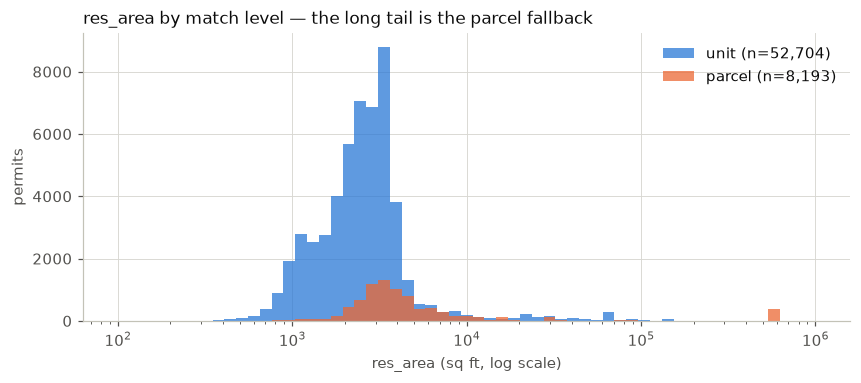

In [25]:
paired = [
    ("unit", BLUE),
    ("parcel", ORANGE),
]

fig, ax = plt.subplots(figsize=(9, 3.4))
bins = np.logspace(np.log10(100), np.log10(1_000_000), 60)
for level, color in paired:
    vals = df.loc[df["match_level"] == level, "res_area"]
    vals = vals[vals > 0]
    ax.hist(vals, bins=bins, color=color, alpha=0.75, label=f"{level} (n={len(vals):,})")
ax.set_xscale("log")
ax.set_title("res_area by match level — the long tail is the parcel fallback")
ax.set_xlabel("res_area (sq ft, log scale)")
ax.set_ylabel("permits")
ax.legend(frameon=False)
plt.show()

The orange distribution is shifted right and much wider — that is the aggregation, not
bad data. A `parcel` row reading 559,416 sq ft is a correct sum over 125 assessment
records; it is simply not a house.

**The practical consequence:** if you filter `res_area` on a single global threshold you
will delete the parcel rows almost exclusively, and with them most of the large
multi-family buildings. If what you want is "single-family-ish housing," filter on
`match_level` and `use_code` — the thing you actually mean — rather than on square footage.

## 5. Numeric distributions

One row per field: percentiles, a histogram, and the extreme rows. The percentile table
is the one to read — it tells you where a cutoff would land and how many rows sit past it.

In [26]:
DETAIL_COLS = ["address", "parcel_prefix", "match_level", "assess_records",
               "year_built", "res_area", "num_rooms", "stories", "use_code", "style"]

def review(col: str, *, log: bool = False, bins: int = 60, show: int = 6, clip=None,
           detail: list[str] | None = None):
    """Percentiles + histogram + the extreme rows for one numeric column.

    `detail` picks the columns shown for the extreme rows. The assessor default
    is useless for a text-extracted figure -- pass the description instead.
    """
    s = df[col]
    valid = s.dropna()
    nonzero = valid[valid > 0]

    qs = [0, 0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999, 1]
    table = pd.DataFrame({
        "all non-null": valid.quantile(qs).values,
        "non-null & > 0": nonzero.quantile(qs).values if len(nonzero) else np.nan,
    }, index=[f"p{q * 100:g}" for q in qs]).round(1)
    print(f"### {col}   n={len(valid):,}  null={s.isna().sum():,}  zero={(valid == 0).sum():,}")
    print(table.to_string())

    plot_vals = nonzero if log else valid
    if clip is not None:
        plot_vals = plot_vals[plot_vals.between(*clip)]
    fig, ax = plt.subplots(figsize=(9, 2.9))
    edges = (np.logspace(np.log10(max(plot_vals.min(), 1e-9)), np.log10(plot_vals.max()), bins)
             if log else bins)
    ax.hist(plot_vals, bins=edges, color=BLUE)
    if log:
        ax.set_xscale("log")
    ax.set_title(f"{col}" + (" (log scale, zeros dropped)" if log else "")
                 + (f" clipped to {clip}" if clip else ""))
    ax.set_ylabel("permits")
    plt.show()

    cols = DETAIL_COLS if detail is None else detail
    print(f"largest {show}:")
    print(df.nlargest(show, col)[cols].to_string())
    print(f"\nsmallest {show} (non-null):")
    print(df.nsmallest(show, col)[cols].to_string())

### year_built   n=61,214  null=836  zero=0
       all non-null  non-null & > 0
p0           1714.0          1714.0
p0.1         1800.0          1800.0
p1           1856.0          1856.0
p5           1885.0          1885.0
p25          1900.0          1900.0
p50          1900.0          1900.0
p75          1920.0          1920.0
p95          2003.0          2003.0
p99          2020.0          2020.0
p99.9        2023.0          2023.0
p100         2024.0          2024.0


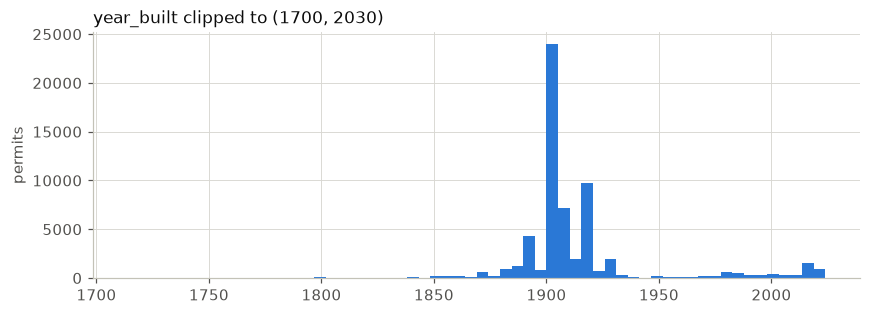

largest 6:
                                                     address parcel_prefix match_level  assess_records  year_built  res_area  num_rooms  stories use_code                style
389         325 ALEWIFE BROOK PKWY, SOMERVILLE MASSACHUSETTS        3-F-35      parcel             5.0      2024.0   11168.0       22.0      2.8     1040           Two Family
614                  16 MEDFORD ST, SOMERVILLE MASSACHUSETTS        97-E-4        unit             1.0      2024.0   50025.0        0.0      4.0     0112  Mid Rise Apartments
732                 21 GLENWOOD RD, SOMERVILLE MASSACHUSETTS       41-D-31        unit             1.0      2024.0    2144.0        9.0      2.0     1010           Two Family
758   325 ALEWIFE BROOK PKWY, SOMERVILLE MASSACHUSETTS 02144        3-F-35      parcel             5.0      2024.0   11168.0       22.0      2.8     1040           Two Family
1269           16 MEDFORD ST, SOMERVILLE MASSACHUSETTS 02143        97-E-4        unit             1.0      2024.0

In [27]:
review("year_built", clip=(1700, 2030))

`year_built` is the best-behaved field here. The floor at 1714 is a plausible-but-checkable
colonial date, the median of 1900 matches Somerville's streetcar-suburb build-out, and
there are no zero sentinels. The one caveat: on `parcel` rows this is a **median across
the building's units**, so a 2015 condo conversion inside an 1890 shell can land anywhere
in between.

Anything after the extract date, or before ~1630, would be a data error. Check the table
above; if the range is clean, this column needs no filter.

### res_area   n=61,377  null=673  zero=480
       all non-null  non-null & > 0
p0              0.0           125.0
p0.1            0.0           410.0
p1            528.8           726.0
p5            971.8          1005.0
p25          1863.0          1890.0
p50          2670.0          2686.0
p75          3456.0          3462.0
p95          8792.0          8842.0
p99         81950.0         81950.0
p99.9      559416.0        559416.0
p100       860111.0        860111.0


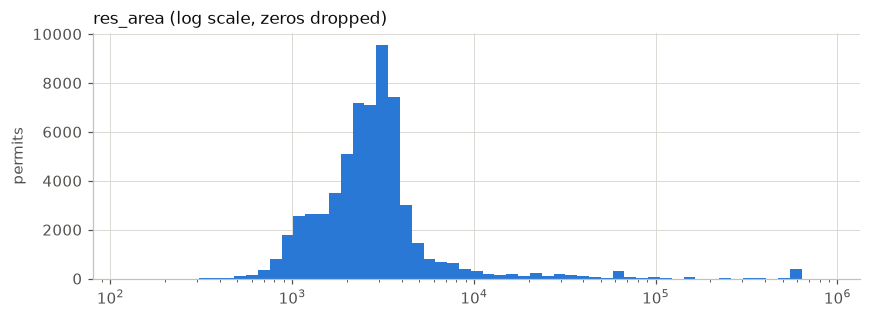

largest 6:
                                                 address parcel_prefix match_level  assess_records  year_built  res_area  num_rooms  stories use_code       style
7711   399 REVOLUTION DR, SOMERVILLE MASSACHUSETTS 02145        99-A-9      parcel             4.0      2015.0  860111.0        0.0     10.5     0336  Pkg Garage
20772             375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020    Mid rise
24263             375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020    Mid rise
24813             375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020    Mid rise
24814             375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020    Mid rise
24815            

In [28]:
review("res_area", log=True)

### num_rooms   n=61,448  null=602  zero=3,146
       all non-null  non-null & > 0
p0              0.0             1.0
p0.1            0.0             2.0
p1              0.0             3.0
p5              0.0             5.0
p25             7.0             8.0
p50            11.0            11.0
p75            14.0            14.0
p95            21.0            21.0
p99            76.5           115.0
p99.9         456.0           456.0
p100          456.0           456.0


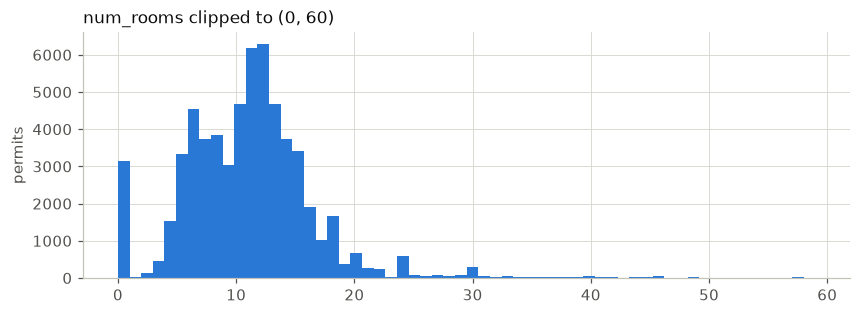

largest 6:
                                      address parcel_prefix match_level  assess_records  year_built  res_area  num_rooms  stories use_code     style
20772  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24263  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24813  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24814  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24815  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
25047  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      20

In [29]:
review("num_rooms", clip=(0, 60))

### stories   n=45,012  null=17,038  zero=0
       all non-null  non-null & > 0
p0              1.0             1.0
p0.1            1.0             1.0
p1              1.5             1.5
p5              1.8             1.8
p25             2.3             2.3
p50             2.5             2.5
p75             2.8             2.8
p95             3.0             3.0
p99            12.0            12.0
p99.9          12.0            12.0
p100           24.0            24.0


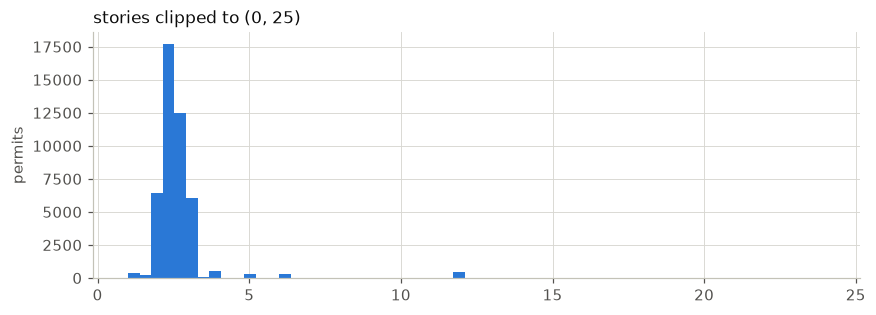

largest 6:
                                          address parcel_prefix match_level  assess_records  year_built  res_area  num_rooms  stories use_code          style
6656   301 ASSEMBLY ROW, SOMERVILLE MASSACHUSETTS       99-A-14        unit             1.0      2019.0  522542.0        0.0     24.0     0112  High Rise Apt
16326  301 ASSEMBLY ROW, SOMERVILLE MASSACHUSETTS       99-A-14        unit             1.0      2019.0  522542.0        0.0     24.0     0112  High Rise Apt
21630      485 FOLEY ST, SOMERVILLE MASSACHUSETTS       99-A-14        unit             1.0      2019.0  522542.0        0.0     24.0     0112  High Rise Apt
30606      485 FOLEY ST, SOMERVILLE MASSACHUSETTS       99-A-14        unit             1.0      2019.0  522542.0        0.0     24.0     0112  High Rise Apt
54536  301 ASSEMBLY ROW, SOMERVILLE MASSACHUSETTS       99-A-14        unit             1.0      2019.0  522542.0        0.0     24.0     0112  High Rise Apt
3747   301 CANAL STREET, SOMERVILLE MASSA

In [30]:
review("stories", clip=(0, 25))

### assess_records   n=61,451  null=599  zero=0
       all non-null  non-null & > 0
p0              1.0             1.0
p0.1            1.0             1.0
p1              1.0             1.0
p5              1.0             1.0
p25             1.0             1.0
p50             1.0             1.0
p75             1.0             1.0
p95             3.0             3.0
p99            20.0            20.0
p99.9         125.0           125.0
p100          125.0           125.0


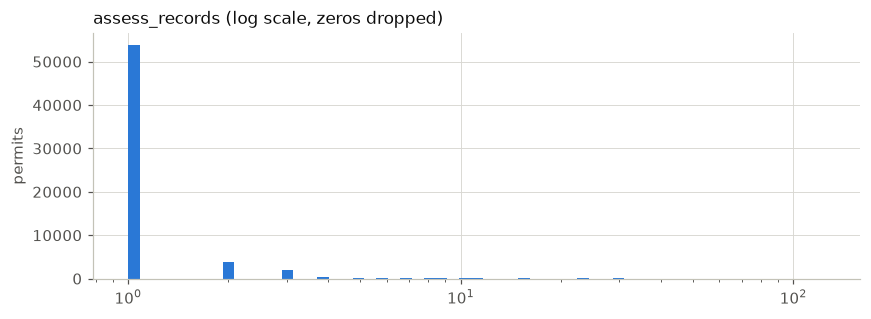

largest 6:
                                      address parcel_prefix match_level  assess_records  year_built  res_area  num_rooms  stories use_code     style
20772  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24263  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24813  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24814  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
24815  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      2015.0  559416.0      456.0     12.0     1020  Mid rise
25047  375 CANAL ST, SOMERVILLE MASSACHUSETTS       85-A-12      parcel           125.0      20

In [31]:
review("assess_records", log=True)

`assess_records` is the count of assessment rows folded into the attributes on that
permit, and it is the cleanest single **flag for how much to trust a row**:

- `1` — one building, attributes are literal.
- `2`–`5` — a two- or three-family, totals are still interpretable as a building.
- `>20` — a large condo or apartment block. `res_area` and `num_rooms` are building sums
  and `year_built`/`stories` are medians over dozens of units.

It is a better filter key than `res_area` because it says *why* a row is large.

### System sizes

`solar_kw` and `ess_kwh` are parsed out of the description text and are populated **only
on rows carrying the matching flag** -- NA everywhere else, including on rows whose
description never states a size. So they have two distinct failure modes, and only the
second is an outlier question:

- **Coverage** -- what fraction of the relevant permits state a size at all. A biased
  gap (say, one installer who never writes kW) skews any average you take.
- **Misreads** -- a number captured that is not the system size.

`solar_kw` already carries a range clip in the pipeline (0.5-500 kW), so the interesting
check is what that clip removed. `ess_kwh` has **no clip at all**.

In [32]:
size_rows = []
for col, flag in zip(SIZE_COLS, ["solar_pv", "ess"]):
    on_flag = df.loc[df[flag], col]
    size_rows.append({
        "column": col,
        "flag": flag,
        "permits with flag": int(df[flag].sum()),
        "with a size": int(on_flag.notna().sum()),
        "coverage %": round(on_flag.notna().mean() * 100, 1),
        "leaked onto non-flag rows": int(df.loc[~df[flag], col].notna().sum()),
    })
pd.DataFrame(size_rows).set_index("column")

,flag,permits with flag,with a size,coverage %,leaked onto non-flag rows
column,,,,,
solar_kw,solar_pv,2374,1998,84.2,0
ess_kwh,ess,63,25,39.7,0


In [33]:
# What did the pipeline's SOLAR_KW_RANGE clip actually remove? A solar row with no
# solar_kw either states no size, or stated one that was rejected.
no_size = df["solar_pv"] & df["solar_kw"].isna()
states_a_number = low.str.contains(r"\d+(?:[.,]\d+)?\s*kw(?!h)", regex=True)
clipped = no_size & states_a_number
print(f"{int(no_size.sum())} solar permits carry no solar_kw")
print(f"  of those, {int(clipped.sum())} DO state a kW figure -- i.e. it was parsed and rejected:\n")
for text in df.loc[clipped, "project_description"]:
    print("  *", " ".join(str(text).split())[:170])

376 solar permits carry no solar_kw
  of those, 1 DO state a kW figure -- i.e. it was parsed and rejected:

  * Installing 31 solar panels on the south facing roof of home. Install SE 10,000 KW and monitoring equipment within 20 ft of MSP.


Near-total coverage of the gap by "states no size" is the good outcome: it means the range
clip is a scalpel, not a filter. The rows it does reject should read as model numbers
("Install SE 10,000 KW" is an inverter part number, not a 10 MW array) rather than
plausible systems -- if a real 600 kW roof shows up here, widen `SOLAR_KW_RANGE`.

### solar_kw   n=1,998  null=60,052  zero=0
       all non-null  non-null & > 0
p0              0.8             0.8
p0.1            1.4             1.4
p1              2.3             2.3
p5              3.0             3.0
p25             4.7             4.7
p50             6.5             6.5
p75             8.4             8.4
p95            13.1            13.1
p99            24.7            24.7
p99.9          79.3            79.3
p100          287.2           287.2


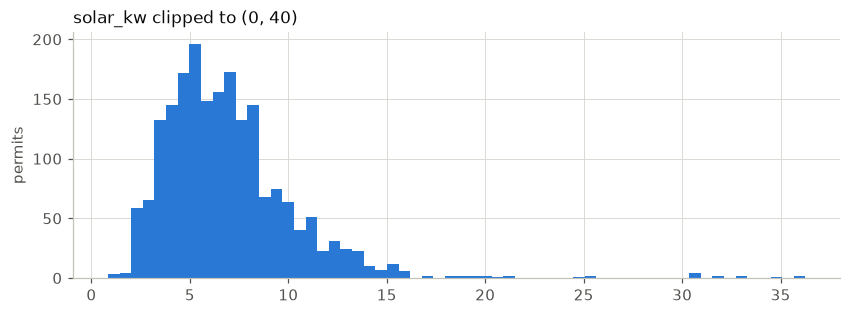

largest 6:
       solar_kw  ess_kwh                                           address                                                                                              project_description
4029     287.18      NaN    1 FITCHBURG ST, SOMERVILLE MASSACHUSETTS 02143                                                                     Construct a 287.18 KW DC rooftop solar array
39933    114.60      NaN        3 MAXWELLS GREEN, SOMERVILLE MASSACHUSETTS  bldg 1 install a 114.6 kW DC solar electric system consisting of 382 solar panels onto existing roof structure.
39658     79.20      NaN        7 MAXWELLS GREEN, SOMERVILLE MASSACHUSETTS   bldg 3 install a 79.2 kW DC solar electric system consisting of 264 solar panels onto existing roof structure.
39932     54.90      NaN  5 MAXWELLS GREEN, SOMERVILLE MASSACHUSETTS 02144   bldg 2 install a 54.9 kW DC solar electric system consisting of 183 solar panels onto existing roof structure.
39656     50.40      NaN        9 MAXWELLS GREEN,

In [34]:
SIZE_DETAIL = ["solar_kw", "ess_kwh", "address", "project_description"]
review("solar_kw", clip=(0, 40), detail=SIZE_DETAIL)

### ess_kwh   n=25  null=62,025  zero=0
       all non-null  non-null & > 0
p0              9.8             9.8
p0.1            9.8             9.8
p1              9.8             9.8
p5             10.5            10.5
p25            13.5            13.5
p50            15.0            15.0
p75            20.2            20.2
p95            27.0            27.0
p99            27.0            27.0
p99.9          27.0            27.0
p100           27.0            27.0


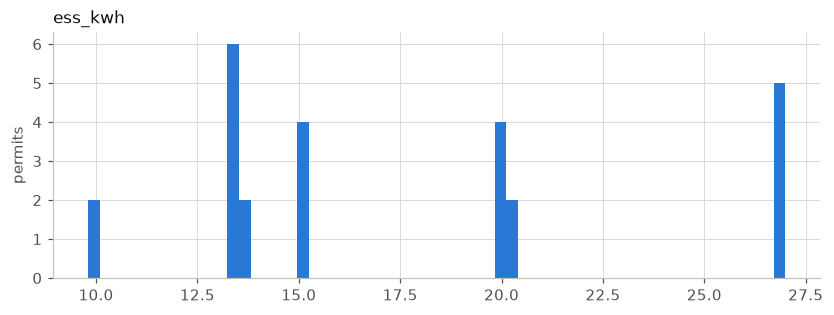

largest 25:
       solar_kw  ess_kwh                                                address                                                                                                                                                                                                               project_description
14738       NaN    27.00        44 COLUMBUS AVE, SOMERVILLE MASSACHUSETTS 02143                                                                                                                               Install Energy Storage System rated at 27kWh outside, interconnected to existing solar panel system
14746       NaN    27.00        44 COLUMBUS AVE, SOMERVILLE MASSACHUSETTS 02143                                                                                                                           Install Energy Storage System rated at 27kWh on exterior, interconnected to existing solar panel system
56845       NaN    27.00         15 WESTWOOD RD, SOMERVILLE MASSACHUSE

In [35]:
review("ess_kwh", show=25, detail=SIZE_DETAIL)   # only 25 rows -- read all of them

**`solar_kw`** should look like a residential rooftop distribution -- a tight mode in the
5-10 kW band with a thin tail into multi-family arrays. The percentile table is the thing
to read: if p99 sits near the top of the plotted window, the clip window is doing more
than removing junk.

**`ess_kwh`** is a handful of rows and no pipeline clip, so it is the one place a bad
parse would pass straight through. The values should cluster on the capacities that
actually ship (13.5 kWh Powerwall, ~20 kWh, 27 kWh stacks). A number far outside that --
especially a round one -- is a misread of some other figure in the description, and given
the row count you can simply read every one of them.

61,976 rows with coordinates; 0 outside the Somerville bbox


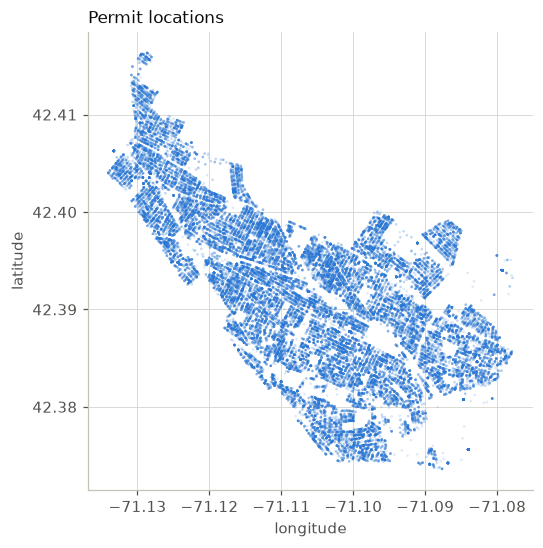

In [36]:
# Geography: everything should sit inside Somerville's bounding box.
SOM_BBOX = dict(lat=(42.37, 42.42), lon=(-71.14, -71.07))

geo = df.dropna(subset=["latitude", "longitude"])
outside = geo[
    ~geo["latitude"].between(*SOM_BBOX["lat"]) | ~geo["longitude"].between(*SOM_BBOX["lon"])
]
print(f"{len(geo):,} rows with coordinates; {len(outside):,} outside the Somerville bbox")

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.scatter(geo["longitude"], geo["latitude"], s=3, alpha=0.15,
           color=BLUE, edgecolors="none", label=f"in bbox (n={len(geo) - len(outside):,})")
if len(outside):
    ax.scatter(outside["longitude"], outside["latitude"], s=26, color=ORANGE,
               edgecolors="white", linewidths=0.5, label=f"outside (n={len(outside):,})")
    ax.legend(frameon=False, loc="best")
ax.set_title("Permit locations")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_aspect(1 / np.cos(np.radians(42.39)))
plt.show()

if len(outside):
    print(outside[["address", "latitude", "longitude", "apn"]].head(10).to_string())

A dense city-shaped blob with no scattered points means geocoding is sound and
`latitude`/`longitude` need no filtering. Stray points are almost always a null island
(0, 0) or a state-plane coordinate that escaped conversion — both obvious in the scatter.

## 6. Filter workbench

Everything above was diagnosis. This is the part to actually turn the dials on.

Each rule below is a named boolean mask. The cells that follow report, for a given
`PARAMS`: how many rows each rule costs, how much the rules overlap, and — the important
one — **whether any rule falls disproportionately on one project type**. A filter that
quietly removes a third of your `solar_pv` rows has changed the answer, not cleaned the data.

The defaults are deliberately conservative: they flag records that are *structurally
unusable* (no assessor match, sentinel zeros) and leave the big-building rows alone, since
section 4 showed those are correct aggregates rather than errors.

In [45]:
PARAMS = dict(
    # --- structural: the row can't support attribute-level analysis ---
    require_assessor_match = True,   # drop match_level.isna()
    require_res_area       = True,   # drop res_area == 0 (assessor sentinel)
    require_year_built     = True,   # drop year_built.isna()

    # --- scope: what counts as a "building" for your question ---
    max_assess_records     = 6,   # e.g. 5 to keep 1-3 family; None = keep all
    unit_matches_only      = False,  # True = drop the parcel-level aggregates entirely

    # --- value ranges ---
    year_built_range       = (1630, 2027),
    res_area_range         = (200, None),      # None = no upper bound
    num_rooms_max          = None,             # e.g. 30

    # --- date coverage ---
    date_range             = (None, None),     # e.g. ("2015-01-01", "2025-12-31")

    # --- geography ---
    require_in_bbox        = True,
)

In [46]:
def build_rules(frame: pd.DataFrame, p: dict) -> dict[str, pd.Series]:
    """Each entry is a mask of rows the rule would REMOVE. Disabled rules are omitted."""
    r: dict[str, pd.Series] = {}
    f = lambda: pd.Series(False, index=frame.index)  # noqa: E731

    if p["require_assessor_match"]:
        r["no assessor match"] = frame["match_level"].isna()
    if p["require_res_area"]:
        r["res_area == 0 (sentinel)"] = frame["res_area"].eq(0)
    if p["require_year_built"]:
        r["year_built missing"] = frame["year_built"].isna()

    if p["max_assess_records"] is not None:
        r[f"assess_records > {p['max_assess_records']}"] = (
            frame["assess_records"] > p["max_assess_records"]
        ).fillna(False)
    if p["unit_matches_only"]:
        r["parcel-level aggregate"] = frame["match_level"].eq("parcel")

    lo, hi = p["year_built_range"]
    if lo is not None or hi is not None:
        m = f()
        if lo is not None:
            m |= frame["year_built"].lt(lo).fillna(False)
        if hi is not None:
            m |= frame["year_built"].gt(hi).fillna(False)
        r[f"year_built outside {p['year_built_range']}"] = m

    lo, hi = p["res_area_range"]
    if lo is not None or hi is not None:
        m = f()
        if lo is not None:
            m |= frame["res_area"].lt(lo).fillna(False) & frame["res_area"].ne(0)
        if hi is not None:
            m |= frame["res_area"].gt(hi).fillna(False)
        r[f"res_area outside {p['res_area_range']}"] = m

    if p["num_rooms_max"] is not None:
        r[f"num_rooms > {p['num_rooms_max']}"] = frame["num_rooms"].gt(p["num_rooms_max"]).fillna(False)

    lo, hi = p["date_range"]
    if lo is not None or hi is not None:
        m = f()
        if lo is not None:
            m |= frame["application_date"] < pd.Timestamp(lo)
        if hi is not None:
            m |= frame["application_date"] > pd.Timestamp(hi)
        r[f"date outside {p['date_range']}"] = m

    if p["require_in_bbox"]:
        r["lat/lon missing or outside bbox"] = ~(
            frame["latitude"].between(*SOM_BBOX["lat"])
            & frame["longitude"].between(*SOM_BBOX["lon"])
        ).fillna(False)

    return r


rules = build_rules(df, PARAMS)
dropped = pd.DataFrame(rules)
any_dropped = dropped.any(axis=1)

cost = pd.DataFrame({
    "rows flagged": dropped.sum(),
    "% of table": (dropped.mean() * 100).round(2),
    "flagged by this rule ONLY": [
        int((dropped[c] & (dropped.sum(axis=1) == 1)).sum()) for c in dropped
    ],
}).sort_values("rows flagged", ascending=False)

print(f"{any_dropped.sum():,} of {len(df):,} rows flagged "
      f"({any_dropped.mean() * 100:.2f}%) -> {(~any_dropped).sum():,} kept\n")
cost

2,246 of 62,050 rows flagged (3.62%) -> 59,804 kept



,rows flagged,% of table,flagged by this rule ONLY
assess_records > 6,1059,1.71,1059
year_built missing,836,1.35,92
no assessor match,599,0.97,0
res_area == 0 (sentinel),480,0.77,335
lat/lon missing or outside bbox,74,0.12,15
"res_area outside (200, None)",1,0.00,1
"year_built outside (1630, 2027)",0,0.00,0


Read the **`flagged by this rule ONLY`** column against `rows flagged`. A rule whose two
numbers are close is doing independent work. A rule whose "only" count is near zero is
redundant — it is catching rows another rule already caught, and you can drop it from
`PARAMS` without changing the output.

In [47]:
# Does any rule land disproportionately on one project type? This is the question that
# decides whether a filter is cleaning data or biasing the result.
# The flags overlap, so there is no "share of total" to compare -- a row can sit in two
# rows of this table. The comparable quantity is each flag's own removal rate against
# the overall rate.
overall = any_dropped.mean() * 100

rows = {}
for label in [*FLAGS, "untagged"]:
    mask = (n_flags == 0) if label == "untagged" else df[label]
    before = int(mask.sum())
    after = int((mask & ~any_dropped).sum())
    rows[label] = {
        "before": before,
        "after": after,
        "removed": before - after,
        "removed_%": round((before - after) / before * 100, 2) if before else np.nan,
    }
summary = pd.DataFrame(rows).T
summary["vs overall (pp)"] = (summary["removed_%"] - overall).round(2)
print(f"overall removal rate: {overall:.2f}%")
summary.sort_values("removed_%", ascending=False)

overall removal rate: 3.62%


,before,after,removed,removed_%,vs overall (pp)
heat_pump_water_heater,41.0,39.0,2.0,4.88,1.26
untagged,43918.0,42090.0,1828.0,4.16,0.54
cooking,2812.0,2712.0,100.0,3.56,-0.06
water_heater,4338.0,4202.0,136.0,3.14,-0.48
ev_charger,318.0,309.0,9.0,2.83,-0.79
other_hvac,6003.0,5854.0,149.0,2.48,-1.14
electrical_panel,3383.0,3301.0,82.0,2.42,-1.20
heat_pumps,1485.0,1468.0,17.0,1.14,-2.48
solar_pv,2374.0,2349.0,25.0,1.05,-2.57
ess,63.0,63.0,0.0,0.00,-3.62


The column to watch is **`vs overall (pp)`** - each flag's removal rate minus the overall
rate, in percentage points. Near zero everywhere means the filter is neutral with respect
to project type and you have genuinely cleaned data.

A flag several points above the overall rate means the filter is **correlated with the
thing you are trying to measure**, and the usual cause is building type: solar and EV
work concentrate in owner-occupied single-families, while the structural rules bite
hardest on condo records (see the `year_built` note below). Removing rows on a criterion
that tracks your outcome variable biases the result no matter how defensible the
criterion looks in isolation.

Rates here do not sum to the overall rate and are not meant to - a multi-flag row is
counted in every row of the table it belongs to.

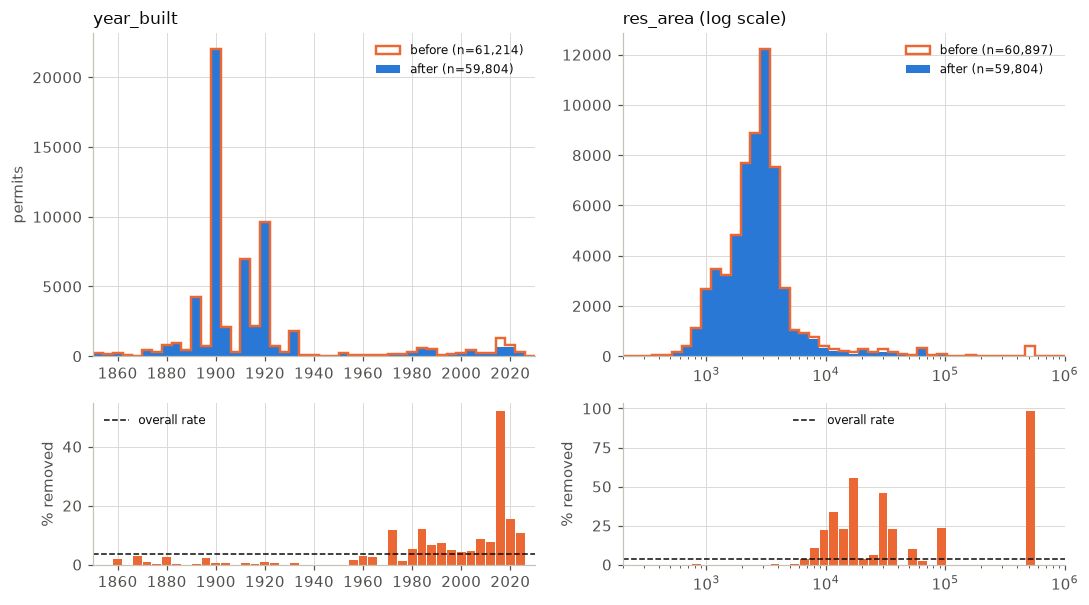

In [48]:
# Where in each distribution do the removals land? A filter that is safe removes rows
# evenly across the range; one that is biased eats a specific part of it.
#
# Top row: the kept distribution (fill) with the full distribution as an outline -- an
# outline can't be hidden underneath, which a second filled histogram would be.
# Bottom row: removal rate per bin, which is the actual question.
SPECS = [
    ("year_built", np.linspace(1850, 2030, 46), False),
    ("res_area", np.logspace(np.log10(200), np.log10(1_000_000), 46), True),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), height_ratios=[2, 1])
for (col, bins, log), top, bot in zip(SPECS, axes[0], axes[1]):
    before = df[col]
    after = df.loc[~any_dropped, col]
    if log:
        before, after = before[before > 0], after[after > 0]

    top.hist(before, bins=bins, histtype="step", color=ORANGE,
             linewidth=1.6, label=f"before (n={before.notna().sum():,})")
    top.hist(after, bins=bins, color=BLUE, label=f"after (n={after.notna().sum():,})")
    top.set_title(col + (" (log scale)" if log else ""))
    top.legend(frameon=False, fontsize=8)

    n_before, _ = np.histogram(before.dropna(), bins=bins)
    n_after, _ = np.histogram(after.dropna(), bins=bins)
    with np.errstate(invalid="ignore", divide="ignore"):
        rate = np.where(n_before > 0, (n_before - n_after) / n_before * 100, np.nan)
    centers = (bins[:-1] + bins[1:]) / 2
    bot.bar(centers, rate, width=np.diff(bins) * 0.9, color=ORANGE)
    bot.axhline(any_dropped.mean() * 100, color=INK, linewidth=1,
                linestyle="--", label="overall rate")
    bot.set_ylabel("% removed")
    bot.legend(frameon=False, fontsize=8)

    for ax in (top, bot):
        if log:
            ax.set_xscale("log")
        ax.set_xlim(bins[0], bins[-1])

axes[0][0].set_ylabel("permits")
fig.tight_layout()
plt.show()

**Reading the bottom row.** The dashed line is the overall removal rate; bars above it are
parts of the distribution the filter hits harder than average.

With the conservative defaults, `res_area` removal is flat and near zero -- no size-based
bias. `year_built` is not flat: removals concentrate in the **1980-2005** band at roughly
4x the overall rate. Worth understanding before you accept it. In that band the removals
come from exactly one rule -- `res_area == 0` (3.3% of the band vs 0.77% overall) -- and
those rows are almost entirely `use_code` 995, `style` "Condominium". Not join failures:
`match_level` is never null in that band. It is the assessor writing a zero-area record
for condo units built in the conversion era.

So the "structural, obviously-safe" `res_area == 0` rule is not uniform -- it is
concentrated on **condominium stock from a specific 25-year window**.

If your question is about older single- and two-family housing, that is harmless. If it
touches condos or recent construction, this default is quietly thinning your subject
population, and you would rather keep those rows and handle the zero some other way --
treat it as NA and impute, or use an analysis that doesn't need `res_area`.

Re-run this section with `require_res_area = False` to see the difference.

In [49]:
# The rows you are about to throw away. Read this before you commit to the thresholds --
# if these look like permits you care about, the thresholds are wrong.
SHOW_RULE = None   # e.g. "no assessor match"; None = a sample across all flagged rows

pool = df[dropped[SHOW_RULE]] if SHOW_RULE else df[any_dropped]
print(f"{len(pool):,} rows flagged by {SHOW_RULE or 'any rule'}\n")
pool.sample(min(15, len(pool)), random_state=0)[
    ["application_date", "application_type", "flag_label", "project_description",
     "address", "match_level", "assess_records", "year_built", "res_area", "num_rooms"]
]

2,246 rows flagged by any rule



,application_date,application_type,flag_label,project_description,address,match_level,assess_records,year_built,res_area,num_rooms
42163,2025-06-25,Electrical Permit,untagged,wire : 3 ground faults receptacles and 3 lights for porch B25-000358,"428 BROADWAY, SOMERVILLE MASSACHUSETTS 02145",NaN,NaN,NaN,NaN,NaN
28009,2016-09-29,Plumbing Permit,untagged,UNIT 1003 Condominiums unit type #2\n52 permits Units all the same,"375 CANAL ST, SOMERVILLE MASSACHUSETTS",parcel,125.0,2015.0,559416.0,456.0
27304,2017-02-02,Plumbing Permit,untagged,UNIT 605 Condominiums unit type #5\n9 units all the same\n,"375 CANAL ST, SOMERVILLE MASSACHUSETTS",parcel,125.0,2015.0,559416.0,456.0
20973,2016-05-11,Electrical Permit,electrical_panel,Common space and service - 3 phase 800A service with 7 x 125A single phase for each co...,"315 HIGHLAND AVE, SOMERVILLE MASSACHUSETTS",parcel,8.0,2015.0,16478.0,49.0
31959,2017-07-13,Electrical Permit,untagged,"Unit 17-717 LV wire phone, data, tv","375 CANAL ST, SOMERVILLE MASSACHUSETTS",parcel,125.0,2015.0,559416.0,456.0
33070,2017-08-08,Electrical Permit,untagged,New decks \n\nNEW CONTRACTOR SEE E18-001078,"43 FRANKLIN ST, SOMERVILLE MASSACHUSETTS 02145",unit,1.0,1930.0,0.0,0.0
47845,2019-03-28,Building Permit,untagged,Unit 86 Renovate kitchen and bathroom,"433 BROADWAY, SOMERVILLE MASSACHUSETTS 02145",NaN,NaN,NaN,NaN,NaN
28340,2016-12-08,Gas Fitting,untagged,Condominiums Gas Permit UNIT 812 \n\n123 permits of this type,"375 CANAL ST, SOMERVILLE MASSACHUSETTS",parcel,125.0,2015.0,559416.0,456.0
9024,2015-04-13,Electrical Permit,untagged,construction of new 30 unit residential building with interior parking garage,"197 WASHINGTON ST, SOMERVILLE MASSACHUSETTS 02143",parcel,31.0,2015.0,31783.0,109.0
6328,2014-11-17,Plumbing Permit,untagged,plumbing unit 1,"21 VILLAGE ST, SOMERVILLE MASSACHUSETTS",parcel,7.0,2014.0,15121.0,39.0


## 7. The filtered table

Once the numbers above look right, this is the frame to carry forward. It is written back
out next to the pipeline output rather than replacing it, so the unfiltered table stays
the source of truth and this decision stays reversible.

In [50]:
clean = df[~any_dropped].copy()

print(f"kept {len(clean):,} of {len(df):,} rows ({len(clean) / len(df) * 100:.2f}%)")
print(f"date range: {clean['application_date'].min():%Y-%m-%d} to {clean['application_date'].max():%Y-%m-%d}")
print(f"assessor match: {clean['match_level'].notna().mean() * 100:.1f}%\n")
print("Active rules:")
for name in cost.index:
    print(f"  - {name}: -{cost.loc[name, 'rows flagged']:,}")
clean.describe(include="all").T

kept 59,804 of 62,050 rows (96.38%)
date range: 2014-02-13 to 2026-09-03
assessor match: 100.0%

Active rules:
  - assess_records > 6: -1,059
  - year_built missing: -836
  - no assessor match: -599
  - res_area == 0 (sentinel): -480
  - lat/lon missing or outside bbox: -74
  - res_area outside (200, None): -1
  - year_built outside (1630, 2027): -0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
application_number,59804,59804,E14-001179,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
application_date,59798,NaN,NaN,NaN,2020-05-14 00:07:35.132278,2014-02-13 00:00:00,2017-04-12 00:00:00,2020-02-20 00:00:00,2023-06-28 00:00:00,2026-09-03 00:00:00,NaN
application_type,59804,4,Building Permit,24399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
application_subtype,59804,9,Residential,17695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_description,59786,48706,Replace Water Heater,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
solar_pv,59804,2,False,57455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
heat_pumps,59804,2,False,58336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
heat_pump_water_heater,59804,2,False,59765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
water_heater,59804,2,False,55602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cooking,59804,2,False,57092,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
# Uncomment when the thresholds are settled. If these rules become permanent,
# move them into scripts/process_somerville_data.py so the pipeline output is
# the filtered table and this notebook goes back to being a check on it.

# OUT = Path("../data/processed/ma/somerville/joined_data_filtered.csv")
# clean.to_csv(OUT, index=False)
# print(f"wrote {len(clean):,} rows to {OUT}")